In [1]:
# Cell 1 - Imports & configuration
import os
import ast
import copy
import json
import re
import shutil
import subprocess
import datetime
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
import torch_geometric.nn as pyg_nn
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.size'] = 14

# Results folder
RESULTS_FOLDER = "Results_cfg_oct23_trial_0"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda:0


In [2]:
# Cell 2 - Offline mocks and small helpers
def get_completion(prompt, model="gpt-3.5-turbo"):
    """Offline mock for LLM responses. By default returns the prompt or a small transformation.
    If you want to simulate a safer/fixed code response, modify this function.
    """
    # For transparency, print short previews when called (won't spam too much)
    preview = prompt[:300].replace('\n', ' ')
    print(f"[get_completion MOCK] prompt_preview={preview!r} len={len(prompt)}")
    # default behavior: return original code if code-like content found
    code_block = re.search(r"```(?:python\n)?([\s\S]*?)```", prompt)
    if code_block:
        return code_block.group(1)
    # fallback: return the prompt itself truncated (or a note)
    return "# [HORS-LIGNE] réponse simulée - laisser inchangé\n" + prompt

def remove_markdown(code: str) -> str:
    match = re.search(r"^```(?:python)?\n([\s\S]*)```$", code)
    if match:
        return match.group(1)
    return code

def calculate_vcs(code, code_filename="temp_code_for_bandit.py"):
    """Run bandit on the provided code and return (cwe_count, cwe_list).
    If bandit fails or not available, returns (0, []).
    """
    with open(code_filename, 'w') as f:
        f.write(code)
    # run bandit
    try:
        cmd = f"bandit -f json {code_filename}"
        res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        out = res.stdout
        if not out:
            # bandit sometimes prints to stderr
            out = res.stderr
        result_json = json.loads(out)
        cwe_set = set()
        for issue in result_json.get('results', []):
            if issue.get('issue_cwe') and 'id' in issue['issue_cwe']:
                cwe_set.add(issue['issue_cwe']['id'])
        cwe_list = sorted(cwe_set)
        return len(cwe_list), cwe_list
    except Exception as e:
        print('[calculate_vcs] bandit error or not installed:', e)
        return 0, []

def estimate_updated_code(original_code, original_graph, updated_graph):
    # Simple heuristic: insert comment lines for newly added nodes and mark deleted nodes
    updated_code_lines = original_code.splitlines()
    deleted_nodes = [n for n in original_graph.nodes if n not in updated_graph.nodes]
    new_nodes = [n for n in updated_graph.nodes if n not in original_graph.nodes]
    for n in new_nodes:
        updated_code_lines.append(f"# New code block for node_{n}")
    for n in deleted_nodes:
        updated_code_lines = [l.replace(f"# Code block for {n}", f"# Deleted code block for {n}") for l in updated_code_lines]
    return "\n".join(updated_code_lines)


In [4]:
# Cell 3 - Minimal stubbed utils (safe fallbacks if utils_new missing)
try:
    from utils_new import (
        extract_graph_from_pyg_data, load_original_code, calc_diff
    )
    print('Imported helpers from utils_new')
except Exception:
    print('utils_new not found - providing fallback implementations')
    def load_original_code(path):
        with open(path, 'r') as f:
            return f.read()
    def extract_graph_from_pyg_data(pyg_data):
        # produce a simple networkx graph from edge_index
        g = nx.DiGraph()
        x = pyg_data.x
        num_nodes = int(x.size(0)) if hasattr(x, 'size') else len(x)
        for i in range(num_nodes):
            g.add_node(i)
        try:
            edges = pyg_data.edge_index.cpu().numpy()
            for a, b in zip(edges[0], edges[1]):
                g.add_edge(int(a), int(b))
        except Exception:
            pass
        return g
    def calc_diff(orig_code, new_code):
        # quick heuristic: fraction of different lines
        o = orig_code.splitlines()
        n = new_code.splitlines()
        matches = sum(1 for a, b in zip(o, n) if a==b)
        return 1 - (matches / max(1, max(len(o), len(n))))


Imported helpers from utils_new


In [5]:
# Cell 4 - Define the Generator/Discriminator (same shapes as demo) and helper converters
in_feats = 1
hidden_feats = 128
out_feats = 1
disc_hidden_feats = 64

class Generator(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super().__init__()
        self.conv1 = pyg_nn.GraphConv(in_feats, hidden_feats)
        self.conv2 = pyg_nn.GraphConv(hidden_feats, out_feats)
        self.relu = nn.ReLU()
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        embeddings_before = self.conv2(x, edge_index)
        updated_x = self.relu(embeddings_before)
        return embeddings_before, updated_x

class Discriminator(nn.Module):
    def __init__(self, in_feats, hidden_feats):
        super().__init__()
        self.conv1 = pyg_nn.GraphConv(in_feats, hidden_feats)
        self.conv2 = pyg_nn.GraphConv(hidden_feats, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.conv2(x, edge_index)
        return self.sigmoid(x)

def adjacency_matrix_to_edge_index(adj_matrix):
    rows, cols = np.where(adj_matrix == 1)
    return torch.tensor([rows, cols], dtype=torch.long)

def create_pyg_data(x, edge_index):
    return Data(x=x, edge_index=edge_index)


In [6]:
# Cell 5 - Load trained models if available, else use identity stubs
generator = Generator(in_feats, hidden_feats, out_feats).to(device)
discriminator = Discriminator(in_feats, disc_hidden_feats).to(device)

gen_path_candidates = [
    'trained_generator_cfg_upd.pt',
    'trained_generator_model.pt',
    os.path.join('models','generator.pt'),
]
disc_path_candidates = [
    'trained_discriminator_cfg_upd.pt',
    'trained_discriminator_model.pt',
    os.path.join('models','discriminator.pt'),
]
loaded_any = False
for p in gen_path_candidates:
    if os.path.exists(p):
        try:
            generator.load_state_dict(torch.load(p, map_location=device))
            loaded_any = True
            print('Loaded generator from', p)
            break
        except Exception as e:
            print('Failed loading', p, e)

for p in disc_path_candidates:
    if os.path.exists(p):
        try:
            discriminator.load_state_dict(torch.load(p, map_location=device))
            loaded_any = True
            print('Loaded discriminator from', p)
            break
        except Exception as e:
            print('Failed loading', p, e)

if not loaded_any:
    print('No pre-trained models found — running with initialized models (behaviour may differ).')

generator.eval(); discriminator.eval()


Loaded generator from trained_generator_model.pt
Loaded discriminator from trained_discriminator_model.pt


/tmp/ipykernel_3760823/1917246996.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load(p, map_location=device))
/tmp/ipykernel_3760823/1

Discriminator(
  (conv1): GraphConv(1, 64)
  (conv2): GraphConv(64, 1)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [7]:
# Cell 6 - Prepare Testing Dataset -> build simple pyg_data_list_test
TEST_FOLDER = 'Testing_DS'
if not os.path.isdir(TEST_FOLDER):
    raise FileNotFoundError(f"Testing_DS folder not found in current directory: {os.getcwd()}")

file_paths = [os.path.join(TEST_FOLDER, f) for f in os.listdir(TEST_FOLDER) if f.endswith('.py')]
file_paths.sort()
print('Found', len(file_paths), 'test files')

pyg_data_list_test = []
for fp in file_paths:
    # generate simple CFG-like graph: one node per non-empty line
    with open(fp, 'r') as f:
        content = f.read()
    lines = [ln for ln in content.splitlines() if ln.strip()!='']
    G = nx.DiGraph()
    for i, _ in enumerate(lines):
        G.add_node(i)
        if i>0:
            G.add_edge(i-1, i)
    adj = nx.adjacency_matrix(G).toarray()
    if len(G.nodes)==0:
        # empty file fallback
        x = torch.zeros((1,1), dtype=torch.float32)
        edge_index = torch.tensor([[0],[0]], dtype=torch.long)
    else:
        node_features = np.zeros((len(G.nodes),1), dtype=np.float32)
        x = torch.tensor(node_features)
        edge_index = adjacency_matrix_to_edge_index(adj)
    pyg_data_list_test.append({'path': fp, 'pyg': Data(x=x, edge_index=edge_index)})
print('Prepared', len(pyg_data_list_test), 'pyg test items')


Found 100 test files
Prepared 100 pyg test items


/tmp/ipykernel_3760823/2874529947.py:35: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor([rows, cols], dtype=torch.long)


In [8]:
# Cell 7 - Core vet_code function (offline-safe)
def vet_code(ci, pyg_data_test_i):
    # g_before as networkx graph
    g_before = extract_graph_from_pyg_data(pyg_data_test_i)
    k_bef, CWEs_bef = calculate_vcs(ci)
    x = pyg_data_test_i.x.to(device)
    edge_index = pyg_data_test_i.edge_index.to(device)
    # run generator to get updated node features
    try:
        embeddings_before, updated_x = generator(x, edge_index)
    except Exception as e:
        # fallback: no change
        print('Generator forward failed, fallback to identity:', e)
        updated_x = x
    # create updated pyg data
    pyg_data_test_i_hat = Data(x=updated_x.detach().cpu(), edge_index=pyg_data_test_i.edge_index.cpu())
    g_after = extract_graph_from_pyg_data(pyg_data_test_i_hat)
    # estimate updated code using heuristic
    ci_hat = estimate_updated_code(ci, g_before, g_after)
    ci_hat = remove_markdown(ci_hat)
    # mock generation of final vetted code: call get_completion mock with ci_hat as prompt
    prompt = f"Generate secure Python code preserving functionality:\n{ci_hat}"
    codei_vetted = get_completion(prompt)
    # ensure returned is string
    if not isinstance(codei_vetted, str):
        codei_vetted = ci
    return codei_vetted, float(torch.mean(torch.abs((updated_x - x).float())).item()), pyg_data_test_i_hat


In [9]:
# Cell 8 - Testing loop (runs vet_code iteratively) and collects metrics
iter_num = 20
top_files = [os.path.basename(d['path']) for d in pyg_data_list_test]
num_files = len(top_files)

remaining_k_arr = [None]*num_files
remaining_cwe_arr = [None]*num_files
k_org_arr = [0]*num_files
CWE_org_arr = [None]*num_files
req_iter_num_arr = [0]*num_files
k_after_1_iter_arr = [0]*num_files
sim_after_1_iter_arr = [0]*num_files

output_folder = os.path.join(RESULTS_FOLDER, 'Fixed_codes')
os.makedirs(output_folder, exist_ok=True)

num_graphs_tested = 0
for idx, entry in enumerate(pyg_data_list_test):
    filename = os.path.basename(entry['path'])
    try:
        ci = load_original_code(entry['path'])
        ci_org = copy.deepcopy(ci)
        k_bef, CWEs_bef = calculate_vcs(ci_org)
        k_org_arr[idx] = k_bef
        CWE_org_arr[idx] = CWEs_bef
        pyg_data_test_i = entry['pyg']
        current_loss1 = None
        for iteration in range(iter_num):
            ci, current_loss1, pyg_data_test_i = vet_code(ci, pyg_data_test_i)
            k, CWEs = calculate_vcs(ci)
            ast_sim = calc_diff(ci_org, ci)
            if iteration == 0:
                k_after_1_iter_arr[idx] = k
                sim_after_1_iter_arr[idx] = current_loss1
            if k == 0:
                req_iter_num_arr[idx] = iteration + 1
                break
            req_iter_num_arr[idx] = iteration + 1
        # save vetted file
        vetted_filename = filename.replace('.py', '_vet.py')
        with open(os.path.join(output_folder, vetted_filename), 'w') as vf:
            vf.write(ci)
        remaining_k_arr[idx] = k
        remaining_cwe_arr[idx] = CWEs
        num_graphs_tested += 1
        print(f"Processed {filename}: k_org={k_bef} -> k_after={k} after {req_iter_num_arr[idx]} iters")
    except Exception as e:
        print('Error processing', filename, e)
        remaining_k_arr[idx] = None
        remaining_cwe_arr[idx] = []
        req_iter_num_arr[idx] = iter_num
        continue

print('Tested total:', num_graphs_tested)


[get_completion MOCK] prompt_preview="Generate secure Python code preserving functionality: from flask import Flask, request, redirect import MySQLdb import hashlib import os  app = Flask(__name__)  @app.route('/register', methods=['POST']) def register():    username = request.form['username']    password = request.form['password']    " len=1138
Syntax error encountered while calculating AST difference.
Processed test_file0.py: k_org=1 -> k_after=0 after 1 iters
[get_completion MOCK] prompt_preview='Generate secure Python code preserving functionality: #copilot mean_prob: 0.5033647406739636 #This file was assembled by gen.py, written by redactedAuthorFirstname redactedAuthorLastname. from flask import Flask, request, redirect import re import hashlib import MySQLdb import os app = Flask(__name_' len=1405
Syntax error encountered while calculating AST difference.
Processed test_file1.py: k_org=1 -> k_after=0 after 1 iters
[get_completion MOCK] prompt_preview='Generate secure Python cod

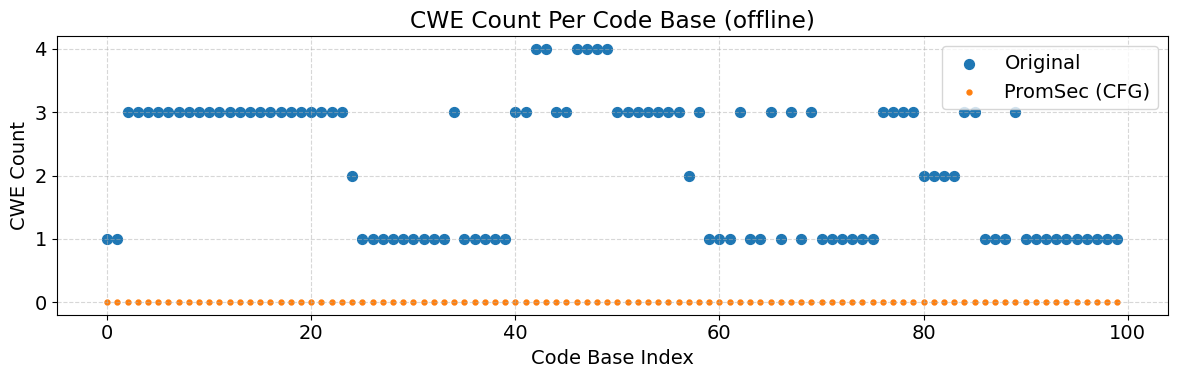

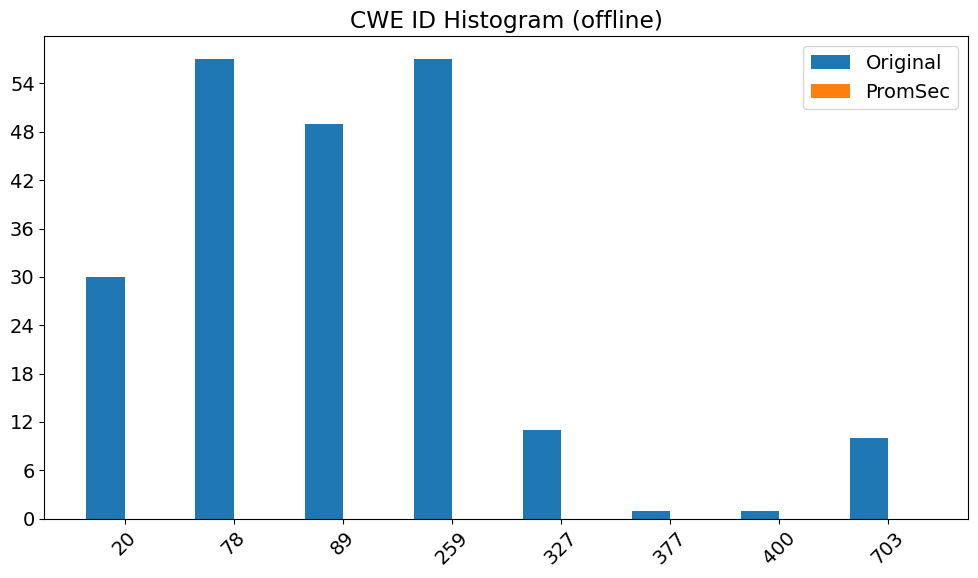

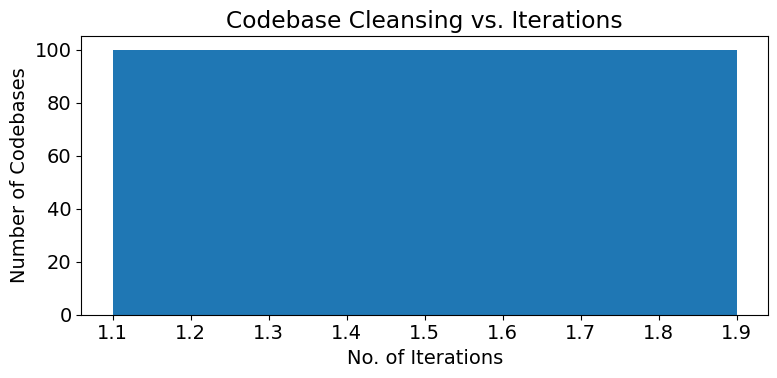

In [10]:
# Cell 9 - Plots
indices = np.arange(len(k_org_arr))
plt.figure(figsize=(12,4))
plt.scatter(indices, k_org_arr, s=50, marker='o', label='Original')
plt.scatter(indices, [0 if v is None else v for v in remaining_k_arr], s=50, marker='.', label='PromSec (CFG)')
plt.xlabel('Code Base Index')
plt.ylabel('CWE Count')
plt.title('CWE Count Per Code Base (offline)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'per_codebase_cfg_offline.png'), dpi=150)
plt.show()

# Per-CWE histogram
org_cwe_freq = Counter([int(x) for sub in (CWE_org_arr if CWE_org_arr else []) for x in (sub or [])])
prop_cwe_freq = Counter([int(x) for sub in (remaining_cwe_arr if remaining_cwe_arr else []) for x in (sub or [])])
all_cwe_ids = sorted(set(org_cwe_freq.keys()) | set(prop_cwe_freq.keys()))
if len(all_cwe_ids) > 0:
    bar_width = 0.35
    r1 = np.arange(len(all_cwe_ids))
    r2 = r1 + bar_width
    fig, ax = plt.subplots(figsize=(10,6))
    bars1 = ax.bar(r1, [org_cwe_freq.get(cwe,0) for cwe in all_cwe_ids], width=bar_width, label='Original')
    bars2 = ax.bar(r2, [prop_cwe_freq.get(cwe,0) for cwe in all_cwe_ids], width=bar_width, label='PromSec')
    ax.set_xticks(r1 + bar_width/2)
    ax.set_xticklabels(all_cwe_ids, rotation=45)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.title('CWE ID Histogram (offline)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_FOLDER, 'per_CWE_cfg_offline.png'), dpi=150)
    plt.show()
else:
    print('No CWE IDs to plot.')

# Iterations histogram
req_iter_num_arr_clean = [int(x) if x is not None else iter_num for x in req_iter_num_arr]
if len(req_iter_num_arr_clean) > 0:
    plt.figure(figsize=(8,4))
    plt.hist(req_iter_num_arr_clean, bins=range(1, max(req_iter_num_arr_clean)+2), rwidth=0.8)
    plt.xlabel('No. of Iterations')
    plt.ylabel('Number of Codebases')
    plt.title('Codebase Cleansing vs. Iterations')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_FOLDER, 'hist_min_required_iterations_cfg_offline.png'), dpi=150)
    plt.show()
else:
    print('No iteration data to plot')
